In [58]:
class LineOrdinalEncoder:

    def __init__(self):
        self.__word_ids = dict()
        self.last_word_id = -1

    def __call__(self, line: str):
        words = line.split(',')
        encoded_line = []
        for w in words:
            if w not in self.__word_ids.keys():
                self.last_word_id += 1
                self.__word_ids[w] = self.last_word_id
            encoded_line.append(self.__word_ids[w])
        return encoded_line

def _ordinal_to_onehot(ordinal_lines: list[list[int]]):
    one_hot_lines = []
    for line in ordinal_lines:
        one_hot_line = 0
        for item_id in line: one_hot_line += 1 << item_id
        one_hot_lines.append(one_hot_line)
    return one_hot_lines

def read_baskets(stream) -> tuple[list[int], int]:
    """:returns: список закодированных в битовые строки транзакций и количество уникальных элементов в транзакциях"""
    ord_encoder = LineOrdinalEncoder()
    encoded_lines = []
    for line in stream.readlines():
        line = line.replace('\n', '')
        encoded_lines.append(ord_encoder(line))
    return _ordinal_to_onehot(encoded_lines), ord_encoder.last_word_id + 1

In [85]:
class ItemSet:

    def __init__(self, bitstring: int):
        # i-й бит кодирует наличие/отсутствие i-го товара в наборе
        self.bitstring = bitstring
        self.count = 0

    def __repr__(self) -> str:
        return "ItemSet([" + ", ".join(self.items) + f"], support = {self.count})"

    @property
    def items(self):
        item_numbers = []
        bitstring_cpy = self.bitstring
        i = 0
        while bitstring_cpy > 0:
            if bitstring_cpy % 2: item_numbers.append(str(i))
            bitstring_cpy >>= 1
            i += 1
        return item_numbers

    def __eq__(self, other): return self.bitstring == other.bitstring

    def __hash__(self): return self.bitstring

In [86]:
from itertools import combinations
from math import log2, floor

def differ_in_exactly_one_item(p: ItemSet, q: ItemSet):
    # Искать транзакции, различающиеся всего одним элементом, можно так: применить побитовое XOR, полученное число логарифмировать, округлить результат вниз и вычесть эту степень двойки из числа; затем логарифмировать снова. Если на втором шаге логарифмирования получается целая степень, пара транзакций подходящая.
    altered_bits = p.bitstring ^ q.bitstring
    power_of_two = floor(log2(altered_bits))
    altered_bits -= 2**power_of_two
    power_of_two = log2(altered_bits)
    EPS = 1e-6

    return abs(power_of_two - round(power_of_two)) <= EPS

def all_item_subsets_present_in_prev_stage(c: ItemSet, prev_stage: list[ItemSet]):
    steps_count = floor(log2(c.bitstring))
    for i in range(steps_count):
        # Если на i-й позиции стоит единица, пробуем занулить ее
        if (c.bitstring >> i) % 2:
            tested_set = c.bitstring - (1 << i)
            if not len([item for item in prev_stage if item.bitstring == tested_set]): return False
    return True

def generate_candidates(prev_stage: list[ItemSet], length: int) -> list[ItemSet]:
    R = set()
    for p, q in combinations(prev_stage, 2):
        if differ_in_exactly_one_item(p, q):
            c = ItemSet(p.bitstring | q.bitstring)
            if all_item_subsets_present_in_prev_stage(c, prev_stage): # Выполняем условие леммы о немонотонности
                R.add(c)
    return list(R)

In [87]:
def apriori(oh_transactions: list[int], supp_threshold: float, unique_items_count: int):
    supp_threshold_abs = supp_threshold * len(oh_transactions)
    
    candidates = [ItemSet(1 << i) for i in range(unique_items_count)]
    for cand in candidates:
        cand.count = len([ta for ta in oh_transactions if cand.bitstring | ta == ta])
    L = [[cand for cand in candidates if cand.count >= supp_threshold_abs]]
    
    k = 2
    while L[-1]:
        candidates = generate_candidates(L[-1], k)
        for cand in candidates:
            cand.count = len([ta for ta in oh_transactions if cand.bitstring | ta == ta])
        L.append([cand for cand in candidates if cand.count >= supp_threshold_abs])
        k += 1
    result = []
    for cand_list in L: result += cand_list
    return result

## Тесты алгоритма

In [88]:
test_set = [
    "1,2,3,4",
    "1,2,4",
    "1,2",
    "2,3,4",
    "2,3",
    "3,4",
    "2,4"
]

encoder = LineOrdinalEncoder()
encoded_set = _ordinal_to_onehot([encoder(line) for line in test_set])

In [89]:
encoded_set

[15, 11, 3, 14, 6, 12, 10]

In [90]:
apriori(encoded_set, 3/7, 4)

[ItemSet([0], support = 3),
 ItemSet([1], support = 6),
 ItemSet([2], support = 4),
 ItemSet([3], support = 5),
 ItemSet([0, 1], support = 3),
 ItemSet([1, 2], support = 3),
 ItemSet([1, 3], support = 4),
 ItemSet([2, 3], support = 3)]

## Задание

In [91]:
FILE = open('baskets.csv',encoding='cp1251')
oh_transactions, unique_items_count = read_baskets(FILE)

In [92]:
unique_items_count

115

In [93]:
len(oh_transactions)

7501

In [ ]:
sorted(apriori(oh_transactions, 0.01, unique_items_count), key=lambda x: x.support)

[ItemSet([0], support = 536),
 ItemSet([1], support = 153),
 ItemSet([10], support = 574),
 ItemSet([100], support = 102),
 ItemSet([106], support = 90),
 ItemSet([11], support = 991),
 ItemSet([0, 11], support = 86),
 ItemSet([12], support = 356),
 ItemSet([14], support = 1788),
 ItemSet([0, 14], support = 177),
 ItemSet([10, 14], support = 180),
 ItemSet([11, 14], support = 233),
 ItemSet([12, 14], support = 113),
 ItemSet([2, 14], support = 87),
 ItemSet([15], support = 319),
 ItemSet([14, 15], support = 128),
 ItemSet([17], support = 475),
 ItemSet([11, 17], support = 84),
 ItemSet([14, 17], support = 152),
 ItemSet([19], support = 494),
 ItemSet([14, 19], support = 207),
 ItemSet([2], support = 250),
 ItemSet([20], support = 654),
 ItemSet([11, 20], support = 131),
 ItemSet([14, 20], support = 183),
 ItemSet([21], support = 157),
 ItemSet([22], support = 1348),
 ItemSet([0, 22], support = 106),
 ItemSet([10, 22], support = 126),
 ItemSet([11, 22], support = 191),
 ItemSet([14, 22]

## Эксперименты

In [121]:
def count_sets(result: list[ItemSet]) -> dict[int, int]:
    """:return: словарь <размер набора - поддержка>"""
    countup = dict()
    for itemset in result:
        itemset_len = len(itemset.items)
        if itemset_len not in countup.keys(): countup[itemset_len] = 0
        countup[itemset_len] += 1
    return countup

In [122]:
import time

time_values = dict()
set_counts = dict() # Количество наборов различной длины по порогам

for threshold_percents in range(1, 16):
    time_start = time.time()
    result = apriori(oh_transactions, threshold_percents / 100, unique_items_count)
    execution_time = time.time() - time_start

    time_values[threshold_percents] = execution_time
    set_counts[threshold_percents] = count_sets(result)

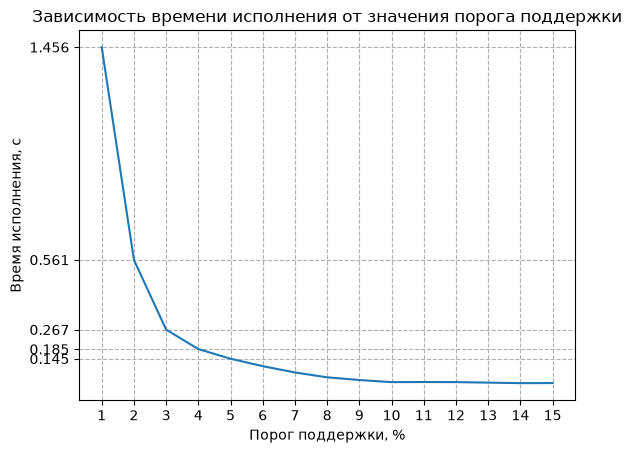

In [123]:
import matplotlib.pyplot as plt

plt.title("Зависимость времени исполнения от значения порога поддержки")
plt.plot(time_values.keys(), time_values.values())
plt.xlabel("Порог поддержки, %")
plt.xticks(list(time_values.keys()))

plt.ylabel("Время исполнения, с")
plt.yticks(list(time_values.values())[:5])

plt.grid(True, ls='--')

plt.show()

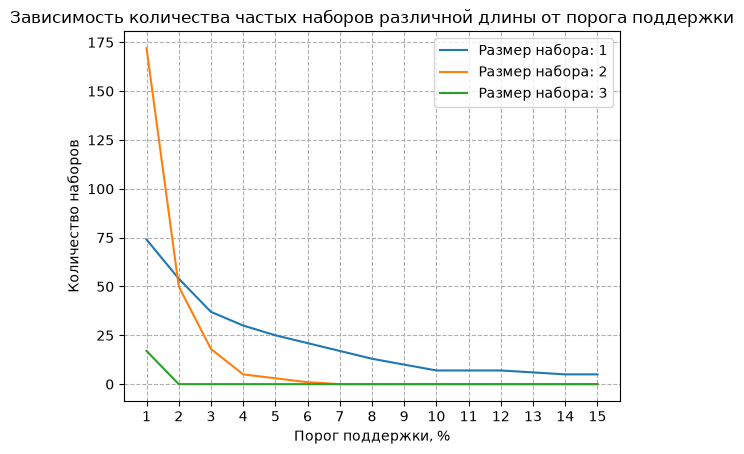

In [129]:
plt.title("Зависимость количества частых наборов различной длины от порога поддержки")
plt.xlabel("Порог поддержки, %")
plt.xticks(list(set_counts.keys()))

plt.ylabel("Количество наборов")

for cardinality in set_counts[1].keys():
    counts_by_threshold = [i.get(cardinality, 0) for i in set_counts.values()]
    plt.plot(range(1, 16), counts_by_threshold, label=f"Размер набора: {cardinality}")

plt.grid(True, ls='--')
plt.legend()
plt.show()

TODO: писать отчет